In [25]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import emcee
from find_source import summary
import corner
import math
from astropy.coordinates import Angle
import astropy.units as units
import scipy.special as sp
import warnings
import itertools
from uncertainties import ufloat

In [26]:
def p_model(p_params, u, v):
    i0, l0, m0 = p_params
    return i0 * np.exp(-2*np.pi*1j*(u*l0 + v*m0))

def c_model(c_params, u, v):
    s0, l0, m0, vis_sigma = c_params
    return s0 * np.exp(-0.5*(u**2 + v**2)/vis_sigma**2) * np.exp(-2*np.pi*1j*(u*l0 + v*m0))

def g_model(g_params, u, v):
    s0, l0, m0, vis_sigma, ratio, vis_theta = g_params
    return s0 * np.exp(-0.5*((u*np.cos(vis_theta)-v*np.sin(vis_theta))**2 + (u*np.sin(vis_theta)+v*np.cos(vis_theta))**2/ratio**2)/vis_sigma**2) \
            * np.exp(-2*np.pi*1j*(u*l0 + v*m0))

def d_model(d_params, u, v):
    s0, l0, m0, vis_r = d_params
    return s0 * 2*vis_r/np.sqrt(u**2+v**2) * sp.j1(np.sqrt(u**2+v**2)/vis_r) * np.exp(-2*np.pi*1j*(u*l0 + v*m0))

In [27]:
def p_p0(peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers):
    p0 = np.zeros((n_walkers, 3))
    for i in range(n_walkers):
        p0[i,0] = np.random.uniform(0.95*peak, 1.05*peak)
        p0[i,1] = np.random.uniform(-rad_pix/2+rad_coord[0], rad_pix/2+rad_coord[0])
        p0[i,2] = np.random.uniform(-rad_pix/2+rad_coord[1], rad_pix/2+rad_coord[1])
    return p0

def c_p0(peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers):
    p0 = np.zeros((n_walkers, 4))
    source_area = rad_barea * total_flux / peak
    sigma = np.sqrt(source_area / (2*np.pi))
    vis_sigma = 1/(2*np.pi*sigma)
    for i in range(n_walkers):
        p0[i,0] = np.random.uniform(0.95*total_flux, 1.05*total_flux)
        p0[i,1] = np.random.uniform(-rad_pix/2+rad_coord[0], rad_pix/2+rad_coord[0])
        p0[i,2] = np.random.uniform(-rad_pix/2+rad_coord[1], rad_pix/2+rad_coord[1])
        p0[i,3] = np.random.uniform(0.95*vis_sigma, 1.05*vis_sigma)
    return p0

def g_p0(peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers):
    p0 = np.zeros((n_walkers, 6))
    source_area = rad_barea * total_flux / peak
    sigma = np.sqrt(source_area / (2*np.pi))
    vis_sigma = 1/(2*np.pi*sigma)
    for i in range(n_walkers):
        p0[i,0] = np.random.uniform(0.95*total_flux, 1.05*total_flux)
        p0[i,1] = np.random.uniform(-rad_pix/2+rad_coord[0], rad_pix/2+rad_coord[0])
        p0[i,2] = np.random.uniform(-rad_pix/2+rad_coord[1], rad_pix/2+rad_coord[1])
        p0[i,3] = np.random.uniform(0.95*vis_sigma, 1.05*vis_sigma)
        p0[i,4] = np.random.uniform(0, 1)
        p0[i,5] = np.random.uniform(-np.pi/2, np.pi/2)
    return p0

def d_p0(peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers):
    p0 = np.zeros((n_walkers, 4))
    source_area = rad_barea * total_flux / peak
    r = np.sqrt(source_area / (2*np.pi))
    vis_r = 1/(math.pi*r)
    for i in range(n_walkers):
        p0[i,0] = np.random.uniform(0.95*total_flux, 1.05*total_flux)
        p0[i,1] = np.random.uniform(-rad_pix/2+rad_coord[0], rad_pix/2+rad_coord[0])
        p0[i,2] = np.random.uniform(-rad_pix/2+rad_coord[1], rad_pix/2+rad_coord[1])
        p0[i,3] = np.random.uniform(0.95*vis_r, 1.05*vis_r)
    return p0

In [28]:
def all_p1(med_sd, n_walkers, chain):
    n_params = len(med_sd)
    p1 = np.zeros((n_walkers, n_params))
    for i in range(n_walkers):
        for j in range(n_params):
            if j in [0, 3, 4]:  # ensure non-negative flux, width parameter, ratio
                p1[i,j] = np.random.uniform(max(-2*med_sd[j][1]+med_sd[j][0], 0), 2*med_sd[j][1]+med_sd[j][0])
                if j == 4:
                    if p1[i,j] == 0:
                        p1[i,j] = np.random.uniform(0.01, 0.05)  # avoid zero ratio
                    if p1[i,j] > 1:
                        p1[i,j] = np.random.uniform(0.96, 1.0)  # cap ratio at 1
            elif j == 5 and med_sd[j][1] > 10 * np.pi/180:  # vis_theta standard devation > 10 degrees
                vis_theta_samples = [params[j] for params in chain]
                neg_vis_thetas = [theta for theta in vis_theta_samples if theta < 0]
                pos_vis_thetas = [theta for theta in vis_theta_samples if theta >= 0]
                neg_med = np.median(neg_vis_thetas) if neg_vis_thetas else None
                pos_med = np.median(pos_vis_thetas) if pos_vis_thetas else None
                if neg_med is not None and pos_med is not None:
                    if abs(abs(neg_med) - pos_med) < 10 * np.pi/180:
                        theta_guess = -np.pi/2
                    else:
                        theta_guess = np.median(vis_theta_samples)
                    p1[i,j] = np.random.uniform(max(theta_guess - np.pi/36, -np.pi/2), theta_guess + np.pi/36)
                else: # at least all between -90 and 0 or all between 0 and 90 degrees
                    p1[i,j] = np.random.uniform(-2*med_sd[j][1]+med_sd[j][0], 2*med_sd[j][1]+med_sd[j][0])
            else:
                p1[i,j] = np.random.uniform(-2*med_sd[j][1]+med_sd[j][0], 2*med_sd[j][1]+med_sd[j][0])
    return p1

In [ ]:
# priors = [[(i0_min, i0_max), (l0_min, l0_max), (m0_min, m0_max), (width_param_min, width_param_max), (ratio_min, ratio_max), (theta_min, theta_max)], ...]
# but (tuple) for exclusive and [list] for inclusive

In [ ]:
def p_prior(params, vis_priors, rad_bmaj, rad_bmin):
    i0, l0, m0 = params
    if vis_priors is not None:
        i0_priors = vis_priors[0]
        l0_priors = vis_priors[1]
        m0_priors = vis_priors[2]
        i0_min, i0_max = i0_priors
        l0_min, l0_max = l0_priors
        m0_min, m0_max = m0_priors

        if i0_min is not None and i0 < i0_min:
            return -np.inf
        if i0_max is not None and i0 > i0_max:
            return -np.inf
        if type(i0_priors) is tuple:
            if i0_min is not None and i0 == i0_min:
                return -np.inf
            if i0_max is not None and i0 == i0_max:
                return -np.inf
        if l0_min is not None and l0 < l0_min:
            return -np.inf
        if l0_max is not None and l0 > l0_max:
            return -np.inf
        if type(l0_priors) is tuple:
            if l0_min is not None and l0 == l0_min:
                return -np.inf
            if l0_max is not None and l0 == l0_max:
                return -np.inf
        if m0_min is not None and m0 < m0_min:
            return -np.inf
        if m0_max is not None and m0 > m0_max:
            return -np.inf
        if type(m0_priors) is tuple:
            if m0_min is not None and m0 == m0_min:
                return -np.inf
            if m0_max is not None and m0 == m0_max:
                return -np.inf
    return 0.0

def c_prior(params, vis_priors, rad_bmaj, rad_bmin):
    s0, l0, m0, vis_sigma = params
    if vis_sigma <= 0: # hardcoded prior
        return -np.inf
    if vis_priors is not None:
        i0_priors = vis_priors[0]
        l0_priors = vis_priors[1]
        m0_priors = vis_priors[2]
        vis_sigma_priors = vis_priors[3]
        i0_min, i0_max = i0_priors
        l0_min, l0_max = l0_priors
        m0_min, m0_max = m0_priors
        vis_sigma_min, vis_sigma_max = vis_sigma_priors

        # convert s0 to i0 for priors
        source_area = 1/(2*np.pi*vis_sigma**2)
        rad_barea = np.pi * rad_bmaj * rad_bmin / (4 * np.log(2))
        n_beams = rad_barea / source_area
        i0 = s0 / n_beams
        if i0_min is not None and i0 < i0_min:
            return -np.inf
        if i0_max is not None and i0 > i0_max:
            return -np.inf
        if type(i0_priors) is tuple:
            if i0_min is not None and i0 == i0_min:
                return -np.inf
            if i0_max is not None and i0 == i0_max:
                return -np.inf
            return -np.inf
        if i0_max is not None and i0 > i0_max:
            return -np.inf
        if type(i0_priors) is tuple:
            if i0_min is not None and i0 == i0_min:
                return -np.inf
            if i0_max is not None and i0 == i0_max:
                return -np.inf
        if l0_min is not None and l0 < l0_min:
            return -np.inf
        if l0_max is not None and l0 > l0_max:
            return -np.inf
        if type(l0_priors) is tuple:
            if l0_min is not None and l0 == l0_min:
                return -np.inf
            if l0_max is not None and l0 == l0_max:
                return -np.inf
        if m0_min is not None and m0 < m0_min:
            return -np.inf
        if m0_max is not None and m0 > m0_max:
            return -np.inf
        if type(m0_priors) is tuple:
            if m0_min is not None and m0 == m0_min:
                return -np.inf
            if m0_max is not None and m0 == m0_max:
                return -np.inf
        if vis_sigma_min is not None and vis_sigma < vis_sigma_min:
            return -np.inf
        if vis_sigma_max is not None and vis_sigma > vis_sigma_max:
            return -np.inf
        if type(vis_sigma_priors) is tuple:
            if vis_sigma_min is not None and vis_sigma == vis_sigma_min:
                return -np.inf
            if vis_sigma_max is not None and vis_sigma == vis_sigma_max:
                return -np.inf
    return 0.0

def g_prior(params, vis_priors, rad_bmaj, rad_bmin):
    s0, l0, m0, vis_sigma, ratio, vis_theta = params
    # hardcoded priors
    if vis_sigma <= 0:
        return -np.inf
    if ratio <= 0:
        return -np.inf
    if ratio > 1:
        return -np.inf
    if vis_theta < -np.pi/2:
        return -np.inf
    if vis_theta > np.pi/2:
        return -np.inf
    if vis_priors is not None:
        i0_priors = vis_priors[0]
        l0_priors = vis_priors[1]
        m0_priors = vis_priors[2]
        vis_sigma_priors = vis_priors[3]
        ratio_priors = vis_priors[4]
        vis_theta_priors = vis_priors[5]
        i0_min, i0_max = i0_priors
        l0_min, l0_max = l0_priors
        m0_min, m0_max = m0_priors
        vis_sigma_min, vis_sigma_max = vis_sigma_priors
        ratio_min, ratio_max = ratio_priors
        vis_theta_min, vis_theta_max = vis_theta_priors

        # convert s0 to i0 for priors
        source_area = 1/(2*np.pi*vis_sigma**2*ratio)
        rad_barea = np.pi * rad_bmaj * rad_bmin / (4 * np.log(2))
        n_beams = rad_barea / source_area
        i0 = s0 / n_beams
        if i0_min is not None and i0 < i0_min:
            return -np.inf
        if i0_max is not None and i0 > i0_max:
            return -np.inf
        if type(i0_priors) is tuple:
            if i0_min is not None and i0 == i0_min:
                return -np.inf
            if i0_max is not None and i0 == i0_max:
                return -np.inf
        if l0_min is not None and l0 < l0_min:
            return -np.inf
        if l0_max is not None and l0 > l0_max:
            return -np.inf
        if type(l0_priors) is tuple:
            if l0_min is not None and l0 == l0_min:
                return -np.inf
            if l0_max is not None and l0 == l0_max:
                return -np.inf
        if m0_min is not None and m0 < m0_min:
            return -np.inf
        if m0_max is not None and m0 > m0_max:
            return -np.inf
        if type(m0_priors) is tuple:
            if m0_min is not None and m0 == m0_min:
                return -np.inf
            if m0_max is not None and m0 == m0_max:
                return -np.inf
        if vis_sigma_min is not None and vis_sigma < vis_sigma_min:
            return -np.inf
        if vis_sigma_max is not None and vis_sigma > vis_sigma_max:
            return -np.inf
        if type(vis_sigma_priors) is tuple:
            if vis_sigma_min is not None and vis_sigma == vis_sigma_min:
                return -np.inf
            if vis_sigma_max is not None and vis_sigma == vis_sigma_max:
                return -np.inf
        if ratio_min is not None and ratio < ratio_min:
            return -np.inf
        if ratio_max is not None and ratio > ratio_max:
            return -np.inf
        if type(ratio_priors) is tuple:
            if ratio_min is not None and ratio == ratio_min:
                return -np.inf
            if ratio_max is not None and ratio == ratio_max:
                return -np.inf
        if vis_theta_min is not None and vis_theta < vis_theta_min:
            return -np.inf
        if vis_theta_max is not None and vis_theta > vis_theta_max:
            return -np.inf
        if type(vis_theta_priors) is tuple:
            if vis_theta_min is not None and vis_theta == vis_theta_min:
                return -np.inf
            if vis_theta_max is not None and vis_theta == vis_theta_max:
                return -np.inf
    return 0.0

def d_prior(params, vis_priors, rad_bmaj, rad_bmin):
    s0, l0, m0, vis_r = params
    if vis_r <= 0: # hardcoded prior
        return -np.inf
    if vis_priors is not None:
        i0_priors = vis_priors[0]
        l0_priors = vis_priors[1]
        m0_priors = vis_priors[2]
        vis_r_priors = vis_priors[3]
        i0_min, i0_max = i0_priors
        l0_min, l0_max = l0_priors
        m0_min, m0_max = m0_priors
        vis_r_min, vis_r_max = vis_r_priors

        # convert s0 to i0 for priors
        source_area = 1/(4*np.pi*vis_r**2)
        rad_barea = np.pi * rad_bmaj * rad_bmin / (4 * np.log(2))
        n_beams = rad_barea / source_area
        i0 = s0 / n_beams
        if i0_min is not None and i0 < i0_min:
            return -np.inf
        if i0_max is not None and i0 > i0_max:
            return -np.inf
        if type(i0_priors) is tuple:
            if i0_min is not None and i0 == i0_min:
                return -np.inf
            if i0_max is not None and i0 == i0_max:
                return -np.inf
        if l0_min is not None and l0 < l0_min:
            return -np.inf
        if l0_max is not None and l0 > l0_max:
            return -np.inf
        if type(l0_priors) is tuple:
            if l0_min is not None and l0 == l0_min:
                return -np.inf
            if l0_max is not None and l0 == l0_max:
                return -np.inf
        if m0_min is not None and m0 < m0_min:
            return -np.inf
        if m0_max is not None and m0 > m0_max:
            return -np.inf
        if type(m0_priors) is tuple:
            if m0_min is not None and m0 == m0_min:
                return -np.inf
            if m0_max is not None and m0 == m0_max:
                return -np.inf
        if vis_r_min is not None and vis_r < vis_r_min:
            return -np.inf
        if vis_r_max is not None and vis_r > vis_r_max:
            return -np.inf
    return 0.0

In [30]:
def log_likelihood(model, re, im, u, v, w):
    return -0.5 * np.sum(w * ((re - model.real)**2 + (im - model.imag)**2))

In [31]:
P_PARAMS = ['i0', 'l0', 'm0']
C_PARAMS = ['s0', 'l0', 'm0', 'vis_sigma']
G_PARAMS = ['s0', 'l0', 'm0', 'vis_sigma', 'ratio', 'vis_theta']
D_PARAMS = ['s0', 'l0', 'm0', 'vis_r']

In [32]:
SOURCE_TYPES = {'p': [3, p_p0, p_prior, p_model, P_PARAMS], \
                'c': [4, c_p0, c_prior, c_model, C_PARAMS], \
                'g': [6, g_p0, g_prior, g_model, G_PARAMS], \
                'd': [4, d_p0, d_prior, d_model, D_PARAMS]}

In [ ]:
def log_probability(params, sources, vis_priors, re, im, u, v, w, rad_bmaj, rad_bmin):
    log_prior = 0.0
    model = 0.0
    start = 0
    l0_list = []
    m0_list = []
    for source in sources:
        n_params = SOURCE_TYPES[source][0]
        prior_func = SOURCE_TYPES[source][2]
        model_func = SOURCE_TYPES[source][3]
        source_params = params[start:start+n_params]
        l0_list.append(source_params[1])
        m0_list.append(source_params[2])
        lp = prior_func(source_params, vis_priors, rad_bmaj, rad_bmin)
        if not np.isfinite(lp):
            return -np.inf
        log_prior += lp
        model += model_func(source_params, u, v)
        start += n_params
    indices = list(range(len(l0_list))) # list of indices for l0_list and m0_list
    pairs = itertools.permutations(indices, 2)
    for (idx1, idx2) in pairs:
        dist = np.sqrt((l0_list[idx1] - l0_list[idx2])**2 + (m0_list[idx1] - m0_list[idx2])**2)
        if dist < rad_bmaj:  # beam major axis as threshold distance to consider sources too close
            return -np.inf
    log_likelihood_value = log_likelihood(model, re, im, u, v, w)
    return log_prior + log_likelihood_value

In [ ]:
def uv_fit(fits_file, sources, priors=None, clean_output=True, corner_plot=True, refine_initial=False):
    # priors = [[(i0_min, i0_max), (l0_min, l0_max), (m0_min, m0_max), (width_param_min, width_param_max), (ratio_min, ratio_max), (theta_min, theta_max)], ...]
    # but (tuple) for exclusive and [list] for inclusive
    # TODO: documentation
    '''
    Fit UV data from a FITS file with specified source types using MCMC.

    Parameters
    ----------
    fits_file (str): Path to the UV FITS file.
    sources (list): List of source types to fit. Each source type should be one of
                    'p' (point), 'c' (circular gaussian), 'g' (gaussian), 'd' (disk), or 'any' (try all and pick best fit).
    '''

    # TODO: check priors format
    # TODO: then change arcsec to radian and width_param to visibility width in priors for when we input it into functions (priors -> vis_priors)

    # Check input source types
    if len(sources) == 0:
        raise ValueError("No sources specified. Try specifying one or more sources of type \
                         'p' (point), 'c' (circular gaussian), 'g' (gaussian), 'd' (disk), or 'any' (try all and pick best fit).")
    for source in sources:
        if source not in SOURCE_TYPES and source != 'any':
            raise ValueError(f"Source type '{source}' is not recognized. Source type must be one of the following: \
                            'p' (point), 'c' (circular gaussian), 'g' (gaussian), 'd' (disk), or 'any' (try all and pick best fit).")

    # Extract data from fits file
    file = fits.open(fits_file)
    cdelt1 = file[0].header['CDELT1']
    cunit1 = file[0].header['CUNIT1']
    naxis1 = file[0].header['NAXIS1']
    naxis2 = file[0].header['NAXIS2']
    data = file[1].data

    summ = summary(fits_file, plot=False)
    bmaj = file[0].header['BMAJ'] # cunit1
    bmin = file[0].header['BMIN'] # cunit1
    rad_bmaj = Angle(bmaj, cunit1).to(units.radian).value
    rad_bmin = Angle(bmin, cunit1).to(units.radian).value
    rad_barea = np.pi * rad_bmaj * rad_bmin / (4 * np.log(2))
    rad_pix = float(Angle(cdelt1, cunit1).to(units.radian).value)
    int_peaks = summ['int_peak_val']
    int_coords = summ['int_peak_coord']
    ext_peaks = summ['ext_peak_val']
    ext_coords = summ['ext_peak_coord']

    int_info = list(zip(int_peaks, int_coords))
    if type(ext_peaks) is list:
        ext_info = list(zip(ext_peaks, ext_coords))
    else:
        ext_info = []
    all_peaks = int_info + ext_info # list of tuples (peak_value, (l_coord, m_coord))
    all_peaks.sort(reverse=True) # sort by peak value
    n_peaks = len(all_peaks)
    if n_peaks < len(sources):
        warnings.warn(f"Number of detected peaks ({n_peaks}) is less than number of sources to fit ({len(sources)}).")

    vis = np.array(data)
    freq_bin, u, v, re, im, w = [], [], [], [], [], []
    for row in vis:
        freq_bin_data, u_data, v_data, re_data, im_data, w_data = row
        freq_bin.append(int(freq_bin_data))
        u.append(int(u_data))
        v.append(int(v_data))
        re.append(float(re_data/w_data))
        im.append(float(im_data/w_data))
        w.append(float(w_data))

    # Adding in conjugate half of data
    freq_bin *= 2
    neg_u = [-1 * val for val in u]
    u += neg_u
    neg_v = [-1 * val for val in v]
    v += neg_v
    re *= 2
    neg_im = [-1 * val for val in im]
    im += neg_im
    w *= 2

    freq_bin = np.array(freq_bin)
    u = np.array(u)
    v = np.array(v)
    re = np.array(re)
    im = np.array(im)
    w = np.array(w)

    file.close() # good practice

    total_flux = np.max((re**2 + im**2)**(1/2))

    # All possible permutations
    n_sources = len(sources)
    sample_space = list(SOURCE_TYPES.keys()) * n_sources
    all_permutations = list(itertools.permutations(sample_space, n_sources))

    for i in range(n_sources):
        if sources[i] != 'any':
            all_permutations = [p for p in all_permutations if p[i] == sources[i]] # remove unwanted permutations
    all_permutations = list(set(all_permutations)) # remove duplicates

    all_results = []
    for permutation in all_permutations:
        # Calculate n_params and n_walkers
        n_params = 0
        for i in range(n_sources):
            source = permutation[i]
            n_params += SOURCE_TYPES[source][0]
        n_walkers = 2 * n_params

        # Initial guesses
        for i in range(n_sources):
            source = permutation[i]
            peak = all_peaks[i][0] if i < n_peaks else all_peaks[-1][0]
            coord0 = all_peaks[i][1] if i < n_peaks else all_peaks[-1][1]
            rad_coord = (float(Angle(coord0[0], units.arcsec).to(units.radian).value), float(Angle(coord0[1], units.arcsec).to(units.radian).value))
            if i == 0:
                p0 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
            else:
                mini_p0 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
                if i >= n_peaks: # edit l0, m0 initial guesses
                    for j in range(n_walkers):
                        mini_p0[j,1] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                        mini_p0[j,2] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                p0 = np.append(p0, mini_p0, axis=1)

        # Set up and run MCMC
        n_steps = 100
        sampler = emcee.EnsembleSampler(n_walkers, n_params, log_probability, args=(permutation, vis_priors, re, im, u, v, w, rad_bmaj, rad_bmin))
        try:
            state = sampler.run_mcmc(p0, n_steps)
        except emcee.autocorr.AutocorrError:
            pass
        tau = sampler.get_autocorr_time(quiet=True)
        if np.isnan(tau).any():
            warnings.warn(f"Autocorrelation time for first run of {permutation} could not be estimated; one or more values are NaN.", RuntimeWarning)
            all_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': None, 'chain': None})
            continue
        int_tau = math.ceil(np.nanmax(tau)/1)
        steps_to_50_tau = int_tau * 50 - n_steps
        sampler.run_mcmc(state, steps_to_50_tau)
        chain = sampler.get_chain(discard = int_tau * 10, flat=True)
        log_probs = sampler.get_log_prob(discard = int_tau * 10, flat=True)
        max_prob_index = np.argmax(log_probs)

        # Find parameter estimates and uncertainties and calculate chi2
        result = {}
        model = 0.0
        start = 0
        for i in range(n_sources):
            source = permutation[i]
            n_source_params = SOURCE_TYPES[source][0]
            source_chain = chain[:, start:start+n_source_params]
            source_result = {'type': source}
            temp_medians = [] # to store medians
            temp_max_probs = [] # to store max prob values
            for j in range(n_source_params):
                samples = source_chain[:, j]
                temp_max_probs.append(samples[max_prob_index])
                samples_med = np.median(samples)
                samples_sd = np.nanstd(samples)
                param_name = SOURCE_TYPES[source][4][j]
                source_result[param_name] = (float(samples_med), float(samples_sd))
                temp_medians.append(samples_med)
            model += SOURCE_TYPES[source][3](temp_max_probs, u, v)
            result[f'source_{i+1}'] = source_result
            start += n_source_params
        chi2 = float(np.sum(w * ((re - model.real)**2 + (im - model.imag)**2)))

        all_results.append({'permutation': permutation, 'n_params': n_params, 'result': result, 'chi2': chi2, 'chain': chain})

    # Do it again with refined initial guesses, if requested
    second_results = []
    if refine_initial:
        for permutation_info in all_results:
            # Calculate n_params and n_walkers
            permutation = permutation_info['permutation']
            chain = permutation_info['chain']
            n_params = 0
            for i in range(n_sources):
                source = permutation[i]
                n_params += SOURCE_TYPES[source][0]
            n_walkers = 2 * n_params

            # New initial guesses from previous results
            for i in range(n_sources):
                source = permutation[i]
                if permutation_info['result'] is None: # fitting didn't happen, so can't actually refine
                    peak = all_peaks[i][0] if i < n_peaks else all_peaks[-1][0]
                    coord0 = all_peaks[i][1] if i < n_peaks else all_peaks[-1][1]
                    rad_coord = (float(Angle(coord0[0], units.arcsec).to(units.radian).value), float(Angle(coord0[1], units.arcsec).to(units.radian).value))
                    if i == 0:
                        p1 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
                    else:
                        mini_p1 = SOURCE_TYPES[source][1](peak, rad_coord, rad_pix, rad_barea, total_flux, n_walkers)
                        if i >= n_peaks: # edit l0, m0 initial guesses
                            for j in range(n_walkers):
                                mini_p1[j,1] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                                mini_p1[j,2] = np.random.uniform(-naxis1/2*rad_pix, naxis1/2*rad_pix)
                        p1 = np.append(p1, mini_p1, axis=1)
                else:
                    source_result = permutation_info['result'][f'source_{i+1}']
                    med_sd = []
                    for param_name in SOURCE_TYPES[source][4]:
                        med_sd.append(source_result[param_name])
                    if i == 0:
                        p1 = all_p1(med_sd, n_walkers, chain)
                    else:
                        p1 = np.append(p1, all_p1(med_sd, n_walkers, chain), axis=1)

            # Set up and run MCMC
            n_steps = 100
            sampler1 = emcee.EnsembleSampler(n_walkers, n_params, log_probability, args=(permutation, vis_priors, re, im, u, v, w, rad_bmaj, rad_bmin))
            try:
                state = sampler1.run_mcmc(p1, n_steps)
            except emcee.autocorr.AutocorrError:
                pass
            tau = sampler1.get_autocorr_time(quiet=True)
            if np.isnan(tau).any():
                warnings.warn(f"Autocorrelation time for second run of {permutation} could not be estimated; one or more values are NaN.", RuntimeWarning)
                second_results.append({'permutation': permutation, 'n_params': n_params, 'result': None, 'chi2': None, 'chain': None})
                continue
            int_tau = math.ceil(np.nanmax(tau)/1)
            steps_to_50_tau = int_tau * 50 - n_steps
            sampler1.run_mcmc(state, steps_to_50_tau)
            chain1 = sampler1.get_chain(discard = int_tau * 10, flat=True)
            log_probs1 = sampler1.get_log_prob(discard = int_tau * 10, flat=True)
            max_prob_index1 = np.argmax(log_probs1)

            # Find parameter estimates and uncertainties and calculate chi2
            result = {}
            model = 0.0
            start = 0
            for i in range(n_sources):
                source = permutation[i]
                n_source_params = SOURCE_TYPES[source][0]
                source_chain = chain1[:, start:start+n_source_params]
                source_result = {'type': source}
                temp_medians = [] # to store medians for chi2 calculation
                temp_max_probs = [] # to store max prob values
                for j in range(n_source_params):
                    samples = source_chain[:, j]
                    temp_max_probs.append(samples[max_prob_index1])
                    samples_med = np.median(samples)
                    samples_sd = np.nanstd(samples)
                    param_name = SOURCE_TYPES[source][4][j]
                    source_result[param_name] = (float(samples_med), float(samples_sd))
                    temp_medians.append(samples_med)
                model += SOURCE_TYPES[source][3](temp_max_probs, u, v)
                result[f'source_{i+1}'] = source_result
                start += n_source_params
            chi2 = float(np.sum(w * ((re - model.real)**2 + (im - model.imag)**2)))

            second_results.append({'permutation': permutation, 'n_params': n_params, 'result': result, 'chi2': chi2, 'chain': chain1})
        all_results = second_results


    # Bayesian Information Criterion
    n = len(re)
    for permutation_info in all_results:
        k = permutation_info['n_params']
        chi2 = permutation_info['chi2']
        if chi2 is None:
            permutation_info['bic'] = np.inf
            continue
        bic = k * np.log(n) + chi2
        permutation_info['bic'] = float(bic)
    all_results.sort(key=lambda x: x['bic']) # lowest to highest BIC

    if clean_output:
        for permutation_info in all_results:
            result = permutation_info['result']
            if result is None:
                continue
            for i in range(n_sources):
                source_key = f'source_{i+1}'
                source_result = result[source_key]
                source_type = source_result['type']
                source_params = SOURCE_TYPES[source_type][4]

                # convert l0, m0 to ra, dec in arcsec
                source_result['ra'] = tuple([float(Angle(l, units.radian).to(units.arcsec).value) for l in source_result['l0']])
                source_result['dec'] = tuple([float(Angle(m, units.radian).to(units.arcsec).value) for m in source_result['m0']])
                del source_result['l0']
                del source_result['m0']

                if source_type != 'p': # convert flux to peak and convert visibility width to image width in arcsec
                    uflux = ufloat(source_result['s0'][0], source_result['s0'][1])
                    uwidth_scale = ufloat(source_result[source_params[3]][0], source_result[source_params[3]][1]) # vis_sigma or vis_r
                    uimg_width_scale = 1/(2*np.pi*uwidth_scale)
                    if source_type == 'c':
                        usource_area = 2 * np.pi * uimg_width_scale**2
                    elif source_type == 'g':
                        uratio = ufloat(source_result['ratio'][0], source_result['ratio'][1])
                        usource_area = 2 * np.pi * uimg_width_scale**2 / uratio
                    elif source_type == 'd':
                        usource_area = np.pi * uimg_width_scale**2
                    n_beams = usource_area / rad_barea
                    peak = uflux / n_beams

                    # Modify dictionary
                    del source_result['s0'] # remove flux values
                    source_result['i0'] = (peak.n, peak.s)
                    del source_result[source_params[3]] # remove visibility width values
                    new_width_key = source_params[3].replace('vis_', '')
                    source_result[new_width_key] = (uimg_width_scale.n, uimg_width_scale.s)

                if source_type == 'g': # convert visibility theta to image theta in degrees and convert sigma and ratio into major and minor
                    uvis_theta = ufloat(source_result['vis_theta'][0], source_result['vis_theta'][1])
                    uimg_theta = (uvis_theta * (180/np.pi) - 90)
                    del source_result['vis_theta']
                    source_result['theta'] = (uimg_theta.n % 90, uimg_theta.s)

                    usigma_min = ufloat(source_result['sigma'][0], source_result['sigma'][1])
                    uratio = ufloat(source_result['ratio'][0], source_result['ratio'][1])
                    usigma_maj = usigma_min / uratio
                    del source_result['sigma']
                    del source_result['ratio']
                    source_result['sigma_maj'] = (usigma_maj.n, usigma_maj.s)
                    source_result['sigma_min'] = (usigma_min.n, usigma_min.s)

    if corner_plot:
        for j in range(len(all_results)):
            permutation_info = all_results[j]
            result = permutation_info['result']
            if result is None:
                continue
            chain = permutation_info['chain']
            start = 0
            end = 0
            for i in range(n_sources):
                source_key = f'source_{i+1}'
                source_result = result[source_key]
                source_type = source_result['type']
                n_params = SOURCE_TYPES[source_type][0]
                source_params = SOURCE_TYPES[source_type][4]
                end += n_params
                if i == n_sources-1:
                    fig = corner.corner(chain[:, start:], labels=source_params)
                else:
                    fig = corner.corner(chain[:, start:end], labels=source_params)
                fig.suptitle(f'Permutation {j+1}: {permutation_info["permutation"]}, source {i+1} of {n_sources}')
                start = end

    for permutation_info in all_results:
        del permutation_info['chain']

    return all_results

    # TODO: TEST ON SIMULATED DATA

N/50 = 2;
tau: [13.22245728  7.41749373 12.02422903 14.03492041]
N/50 = 2;
tau: [12.23940842 10.36536029  7.16992348]
N/50 = 2;
tau: [13.24985376 12.65565748 12.23833678 13.45272429 11.85978313  9.10405104]
N/50 = 2;
tau: [13.18222833 11.68589996 11.28100633 12.6257676 ]
N/50 = 2;
tau: [10.48454168 11.06288655 12.82573598 12.86185877]
N/50 = 2;
tau: [8.54721844 9.5942076  7.57782138]
N/50 = 2;
tau: [12.2393094  12.55454942 12.74280702 11.86299113  7.52442879 10.96203645]
N/50 = 2;
tau: [8.39015856 8.10518995 9.342259   8.07748183]


[{'permutation': ('p',),
  'n_params': 3,
  'result': {'source_1': {'type': 'p',
    'i0': (2.4240674412554415, 0.012064068318884437),
    'ra': (0.005819830522943991, 0.004496322805204025),
    'dec': (-0.011188470419374551, 0.0029637155545815014)}},
  'chi2': 7471.081529518098,
  'bic': 7492.713984878515},
 {'permutation': ('c',),
  'n_params': 4,
  'result': {'source_1': {'type': 'c',
    'ra': (0.20791298199513733, 0.02023786962772081),
    'dec': (-0.2640818552371647, 0.02565310572578362),
    'i0': (3.0754654081062687, 0.2687251115646349),
    'sigma': (3.901206403402633e-06, 1.6657523967256784e-07)}},
  'chi2': 18592.088415891594,
  'bic': 18620.93168970548},
 {'permutation': ('d',),
  'n_params': 4,
  'result': {'source_1': {'type': 'd',
    'ra': (0.8881708893425411, 2.0006236230196244),
    'dec': (0.38781493438904313, 2.5352323368555196),
    'i0': (0.8832609798713769, 0.7709311081793405),
    'r': (3.141714697627412e-05, 1.2861060605973722e-05)}},
  'chi2': 24897.8436561074

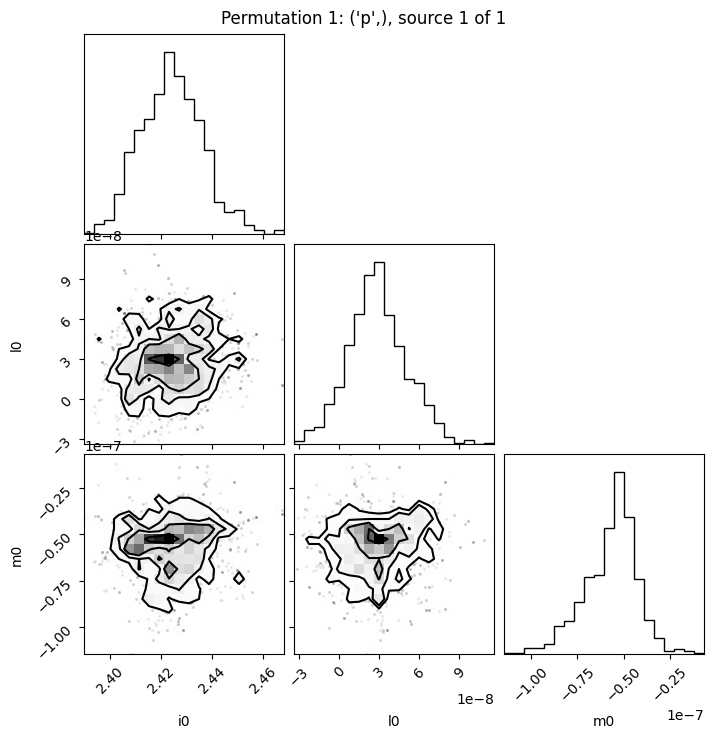

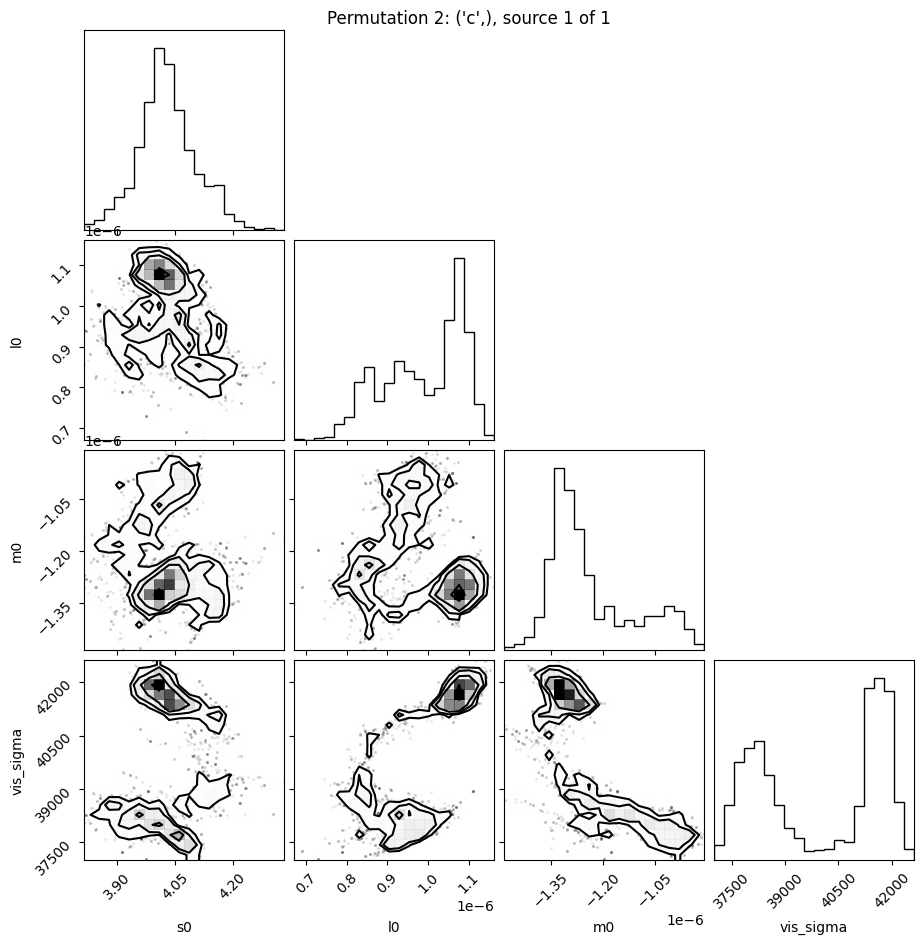

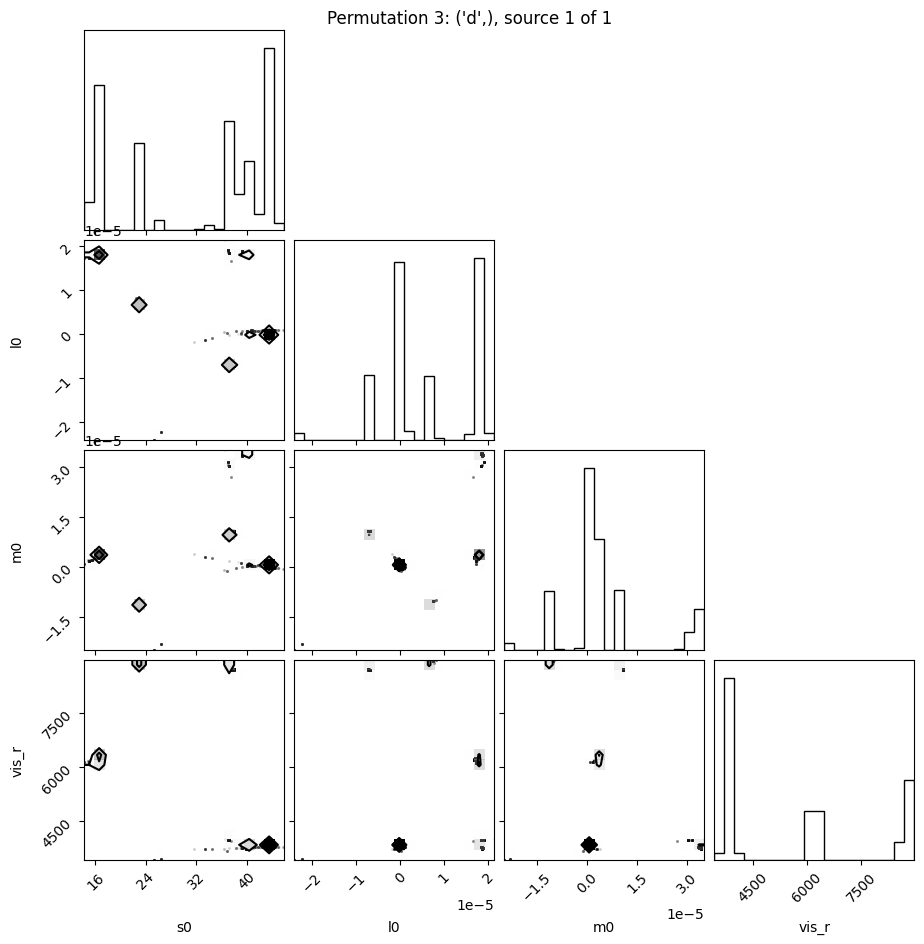

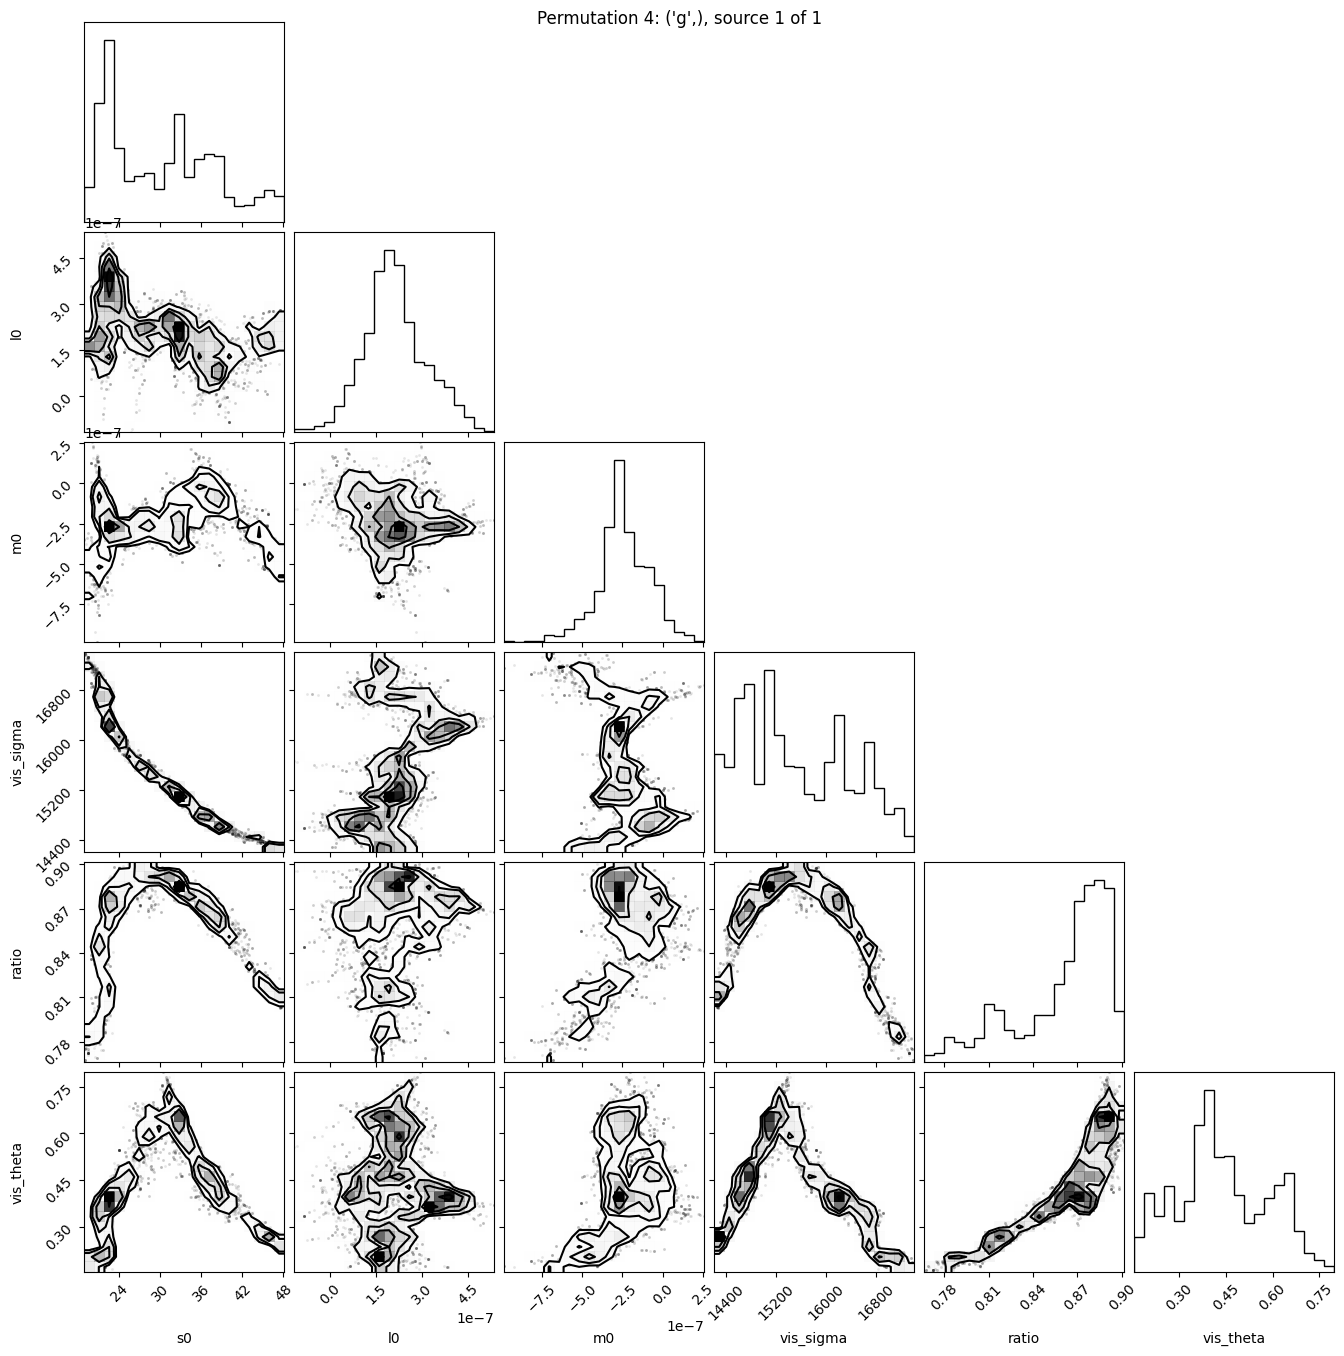

In [35]:
uv_fit('../data/uv_test/3c84.uvfits', sources=['any'], clean_output=True, corner_plot=True, refine_initial=True)

In [36]:
'''
[{'permutation': ('p',),
  'n_params': 3,
  'result': {'source_1': {'type': 'p',
    'i0': (2.427400643825655, 0.01271222168942914),
    'ra': (0.005418295041304301, 0.004496328114315045),
    'dec': (-0.010679824835445722, 0.0032542661406991004)}},
  'chi2': 7471.094720147428,
  'bic': 7492.727175507845},
 {'permutation': ('d',),
  'n_params': 4,
  'result': {'source_1': {'type': 'd',
    'ra': (0.06426410429860518, 0.048857974240688315),
    'dec': (0.0291843563007871, 0.04014692951145933),
    'i0': (6.835397447004499, 3.0479560672055226),
    'r': (0.623299741185465, 0.2609413235266746)}},
  'chi2': 8214.583382457193,
  'bic': 8243.426656271082},
 {'permutation': ('g',),
  'n_params': 6,
  'result': {'source_1': {'type': 'g',
    'ra': (0.4860949525152863, 0.11047736224147069),
    'dec': (-0.19312999265077063, 0.07499595408519567),
    'i0': (2.691069922221008, 0.5274643775053683),
    'theta': (2.0781657869225683, 24.561226809910778),
    'sigma_maj': (1.6618119174907768, np.float64(0.5321827753955112)),
    'sigma_min': (0.7136156079843965, 0.10027919536207161)}},
  'chi2': 24206.914703957314,
  'bic': 24250.17961467815},
 {'permutation': ('c',),
  'n_params': 4,
  'result': {'source_1': {'type': 'c',
    'ra': (-0.47452256643075, 0.3582079162129907),
    'dec': (-0.25062896764570136, 0.49729419673447717),
    'i0': (1.0584668919902014, 0.07050832192416208),
    'sigma': (1.6599267588499145, 0.06447476939585928)}},
  'chi2': 32187.261201895548,
  'bic': 32216.104475709435}]'''

"\n[{'permutation': ('p',),\n  'n_params': 3,\n  'result': {'source_1': {'type': 'p',\n    'i0': (2.427400643825655, 0.01271222168942914),\n    'ra': (0.005418295041304301, 0.004496328114315045),\n    'dec': (-0.010679824835445722, 0.0032542661406991004)}},\n  'chi2': 7471.094720147428,\n  'bic': 7492.727175507845},\n {'permutation': ('d',),\n  'n_params': 4,\n  'result': {'source_1': {'type': 'd',\n    'ra': (0.06426410429860518, 0.048857974240688315),\n    'dec': (0.0291843563007871, 0.04014692951145933),\n    'i0': (6.835397447004499, 3.0479560672055226),\n    'r': (0.623299741185465, 0.2609413235266746)}},\n  'chi2': 8214.583382457193,\n  'bic': 8243.426656271082},\n {'permutation': ('g',),\n  'n_params': 6,\n  'result': {'source_1': {'type': 'g',\n    'ra': (0.4860949525152863, 0.11047736224147069),\n    'dec': (-0.19312999265077063, 0.07499595408519567),\n    'i0': (2.691069922221008, 0.5274643775053683),\n    'theta': (2.0781657869225683, 24.561226809910778),\n    'sigma_maj': (